# Reproduction: Evolution of Stress within a Spherical Insertion Electrode Particle
## Cheng & Verbrugge, *J. Power Sources* 190 (2009) 453–460

Numerical reproduction using Crank-Nicolson Finite Difference Method

**Key dimensionless variables:** $x = r/R$, $\tau = Dt/R^2$

**Stress normalization:**
- Potentiostatic: $\sigma / [E\Omega(C_R-C_0)/(3(1-\nu))]$
- Galvanostatic: $\sigma / [E\Omega \cdot IR/(3(1-\nu)FD)]$

**Strain energy normalization (Eq 19):**
$$\frac{E_T}{2\pi R^3 E [\Omega \Delta c/(3(1-\nu))]^2}$$


In [10]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import rcParams
rcParams.update({'font.family':'serif','font.size':12,'axes.linewidth':1.2,
                 'figure.dpi':120,'figure.figsize':(8,6)})

## 1. Crank-Nicolson Finite Difference Method

The spherical diffusion PDE $\partial c/\partial\tau = x^{-2}\partial_x(x^2\partial_x c)$ is discretized with the Crank-Nicolson scheme.

At $x=0$, L'Hôpital gives $\partial c/\partial\tau = 3\,\partial^2 c/\partial x^2$, discretized using a symmetry ghost point $c_{-1}=c_1$.

With $s=\Delta\tau/(2\Delta x^2)$, the tridiagonal system coefficients for interior points $i=1\ldots N-1$ are:
- Sub: $-s(i-1)/i$, Diag: $1+2s$, Super: $-s(i+1)/i$


In [11]:
def solve_diffusion(N=200, tau_max=0.5, dt_factor=0.5, bc_type='potentiostatic', save_at=None):
    dx = 1.0/N; x = np.linspace(0,1,N+1); dtau = dt_factor*dx**2
    n_steps = int(tau_max/dtau)+1; s = dtau/(2.0*dx**2)
    A = np.zeros((N+1,N+1)); B = np.zeros((N+1,N+1))
    # Center (L'Hopital)
    A[0,0]=1+6*s; A[0,1]=-6*s; B[0,0]=1-6*s; B[0,1]=6*s
    for i in range(1,N):
        A[i,i-1]=-s*(i-1)/i; A[i,i]=1+2*s; A[i,i+1]=-s*(i+1)/i
        B[i,i-1]= s*(i-1)/i; B[i,i]=1-2*s; B[i,i+1]= s*(i+1)/i
    if bc_type=='potentiostatic':
        A[N,N]=1.0
    else:
        # Ghost point: c_{N+1} = c_{N-1} + 2*dx (from dc/dx|_surface = 1)
        # Substitute into interior formula at i=N
        i=N; a_sub=-s*(i-1)/i; a_sup=-s*(i+1)/i
        A[N,N-1]=a_sub+a_sup; A[N,N]=1+2*s
        b_sub=s*(i-1)/i; b_sup=s*(i+1)/i
        B[N,N-1]=b_sub+b_sup; B[N,N]=1-2*s
        _galv_const = (-a_sup + b_sup)*2*dx  # constant from ghost point
    c = np.zeros(N+1); tau_saved=[]; C_saved=[]
    for n in range(n_steps):
        tau_now = (n+1)*dtau; rhs = B@c
        if bc_type=='potentiostatic': rhs[N]=1.0
        else: rhs[N] += _galv_const
        c = np.linalg.solve(A, rhs)
        if save_at is not None:
            for ts in save_at:
                if abs(tau_now-ts)<dtau/2 and ts not in tau_saved:
                    tau_saved.append(tau_now); C_saved.append(c.copy())
        else:
            tau_saved.append(tau_now); C_saved.append(c.copy())
    return x, np.array(tau_saved), np.array(C_saved)

## 2. Stress & Energy Functions (Matching Paper Eqs. 3, 6, 7)

The paper normalizes stresses by $E\Omega\Delta c/(3(1-\nu))$. In our dimensionless concentration $c$, the stresses become:

$$\tilde{\sigma}_r = \frac{2}{3}[\bar{c}(1) - \bar{c}(x)], \quad \tilde{\sigma}_\theta = \frac{1}{3}[2\bar{c}(1) + \bar{c}(x) - 3c(x)]$$

where $\bar{c}(x) = (3/x^3)\int_0^x y^2 c(y)dy$.

The strain energy (Eq 19) is normalized by $2\pi R^3 E[\Omega\Delta c/(3(1-\nu))]^2$:
$$\tilde{E}_T = \int_0^1 [\tilde\sigma_r^2 + 2\tilde\sigma_\theta^2 - 2\nu\tilde\sigma_\theta(2\tilde\sigma_r+\tilde\sigma_\theta)]x^2 dx$$


In [12]:
def compute_c_avg(x, c):
    c_avg = np.zeros_like(c); c_avg[0] = c[0]
    for j in range(1, len(x)):
        integrand = x[:j+1]**2 * c[:j+1]
        c_avg[j] = 3.0/x[j]**3 * np.trapezoid(integrand, x[:j+1])
    return c_avg

def compute_stresses(x, c):
    """Returns dimensionless stresses normalized by E*Omega*Dc/(3*(1-nu))."""
    c_avg = compute_c_avg(x, c)
    # From Eq.(3): sigma_r = (2/3)*E*Omega/(3*(1-nu)) * [Cav(R)-Cav(r)] / Dc
    # In normalized form with c = (C-C0)/Dc:
    sig_r = (2.0/3.0)*(c_avg[-1] - c_avg)
    sig_t = (1.0/3.0)*(2.0*c_avg[-1] + c_avg - 3.0*c)
    return sig_r, sig_t

def compute_shear(sig_r, sig_t):
    """Shear = (sig_r - sig_t)/2, but paper normalizes by 2*E*Omega*Dc/(3*(1-nu))."""
    return (sig_r - sig_t) / 2.0

def compute_strain_energy(x, sig_r, sig_t, nu):
    """Eq.(19)/(28): integral of stress invariant over dimensionless volume."""
    integrand = (sig_r**2 + 2*sig_t**2 - 2*nu*sig_t*(2*sig_r+sig_t)) * x**2
    return np.trapezoid(integrand, x)

## 3. Figure 1: Potentiostatic — Concentration & Stress Profiles

Fig. 1 from the paper shows (a) concentration, (b) radial stress, (c) tangential stress, and (d) shear stress vs $x=r/R$ at dimensionless times $\tau = 0.01, 0.02, 0.05, 0.1, 0.2, 0.5$.

Stresses normalized by $E\Omega(C_R-C_0)/(3(1-\nu))$.


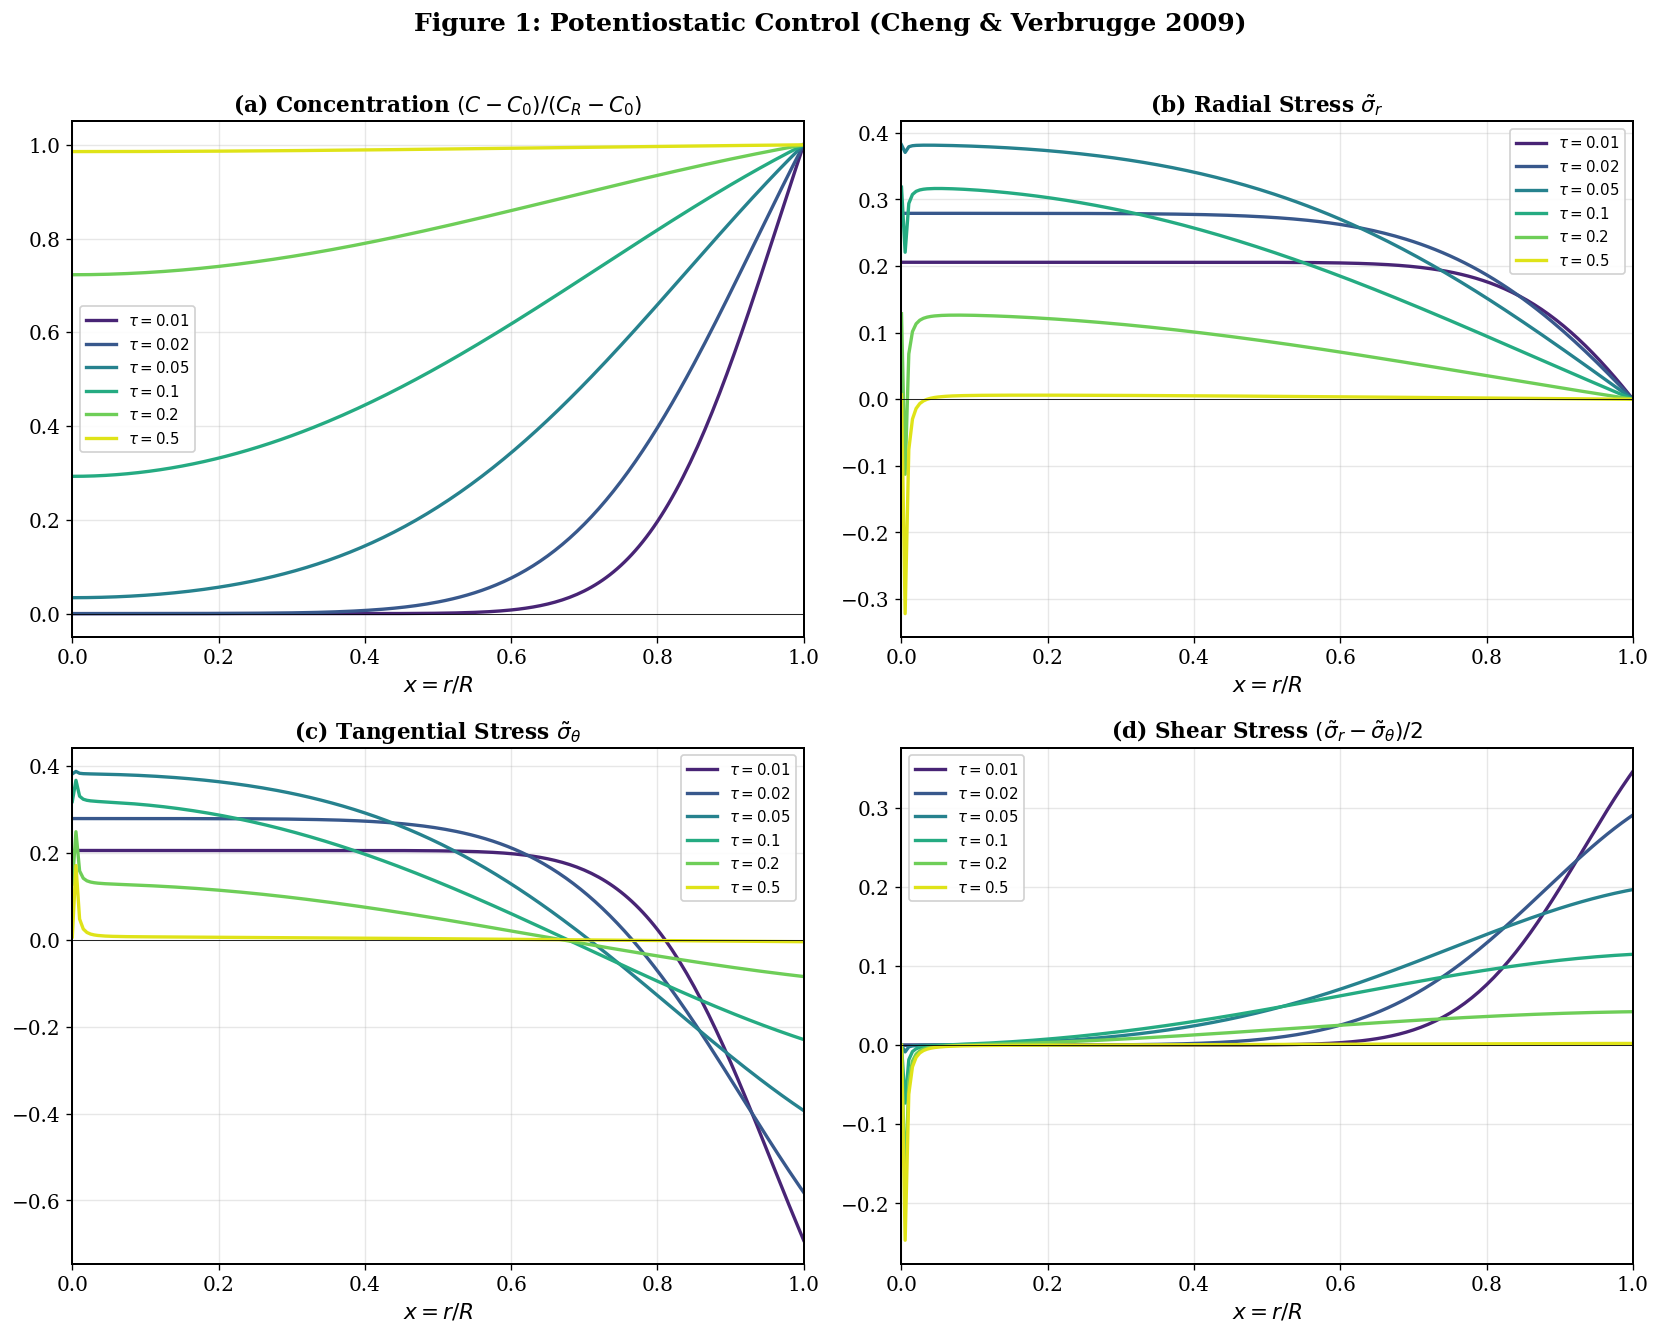

Max radial stress at center (tau~0.057): 0.0067
Paper Eq.16 predicts ~0.4*E*Omega*Dc/(3*(1-nu)), i.e., ~0.133 in our units


In [13]:
tau_vals = [0.01, 0.02, 0.05, 0.1, 0.2, 0.5]
x, tau_s, C_s = solve_diffusion(N=200, tau_max=0.55, bc_type='potentiostatic', save_at=tau_vals)

fig, axes = plt.subplots(2, 2, figsize=(14, 11))
colors = plt.cm.viridis(np.linspace(0.1, 0.95, len(tau_vals)))

for tau_t, col in zip(tau_vals, colors):
    ic = np.argmin(np.abs(tau_s - tau_t))
    c_prof = C_s[ic]
    sr, st = compute_stresses(x, c_prof)
    sh = compute_shear(sr, st)
    lbl = f'$\\tau={tau_t}$'
    axes[0,0].plot(x, c_prof, color=col, lw=2, label=lbl)
    axes[0,1].plot(x, sr, color=col, lw=2, label=lbl)
    axes[1,0].plot(x, st, color=col, lw=2, label=lbl)
    axes[1,1].plot(x, sh, color=col, lw=2, label=lbl)

titles = ['(a) Concentration $(C-C_0)/(C_R-C_0)$',
          '(b) Radial Stress $\\tilde{\\sigma}_r$',
          '(c) Tangential Stress $\\tilde{\\sigma}_\\theta$',
          '(d) Shear Stress $(\\tilde{\\sigma}_r-\\tilde{\\sigma}_\\theta)/2$']
for ax, ttl in zip(axes.flat, titles):
    ax.set_xlabel('$x = r/R$', fontsize=13)
    ax.set_title(ttl, fontsize=13, fontweight='bold')
    ax.legend(fontsize=9, framealpha=0.9)
    ax.grid(True, alpha=0.3); ax.set_xlim(0,1)
    ax.axhline(0, color='k', lw=0.5)

fig.suptitle('Figure 1: Potentiostatic Control (Cheng & Verbrugge 2009)',
             fontsize=15, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('fig1_potentiostatic.png', dpi=150, bbox_inches='tight')
plt.show()
print("Max radial stress at center (tau~0.057):", f"{sr.max():.4f}")
print("Paper Eq.16 predicts ~0.4*E*Omega*Dc/(3*(1-nu)), i.e., ~0.133 in our units")

## 4. Figure 2: Potentiostatic Strain Energy vs Time

Dimensionless strain energy $\tilde{V}(\nu, \tau)$ (Eq. 19) for $-1 < \nu < 0.5$.


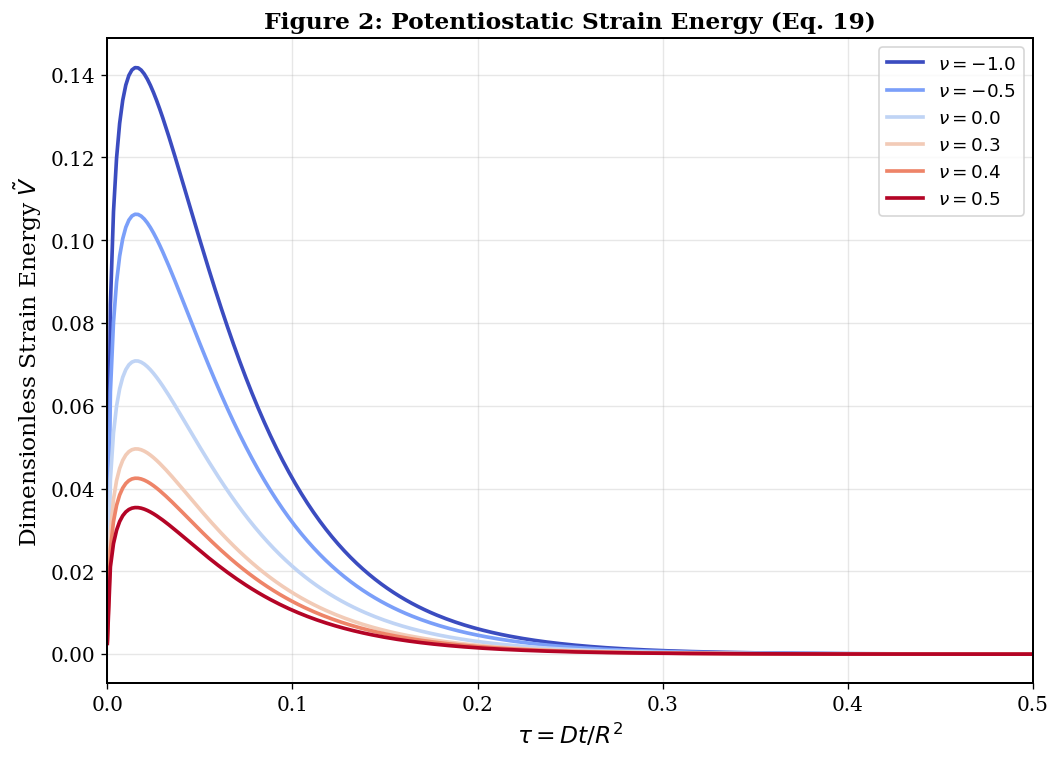

In [14]:
nu_values = [-1.0, -0.5, 0.0, 0.3, 0.4, 0.5]
x_e, tau_e, C_e = solve_diffusion(N=200, tau_max=0.5, bc_type='potentiostatic')
step = max(1, len(tau_e)//300)
tau_sam = tau_e[::step]; C_sam = C_e[::step]

fig, ax = plt.subplots(figsize=(9, 6.5))
cmap = plt.cm.coolwarm(np.linspace(0, 1, len(nu_values)))

for nu, col in zip(nu_values, cmap):
    E_vals = []
    for cp in C_sam:
        sr, st = compute_stresses(x_e, cp)
        E_vals.append(compute_strain_energy(x_e, sr, st, nu))
    ax.plot(tau_sam, E_vals, color=col, lw=2.2, label=f'$\\nu={nu}$')

ax.set_xlabel('$\\tau = Dt/R^2$', fontsize=14)
ax.set_ylabel('Dimensionless Strain Energy $\\tilde{V}$', fontsize=14)
ax.set_title('Figure 2: Potentiostatic Strain Energy (Eq. 19)', fontsize=14, fontweight='bold')
ax.legend(fontsize=11); ax.grid(True, alpha=0.3); ax.set_xlim(0,0.5)
plt.tight_layout()
plt.savefig('fig2_strain_energy_potentiostatic.png', dpi=150, bbox_inches='tight')
plt.show()

## 5. Figure 3: Galvanostatic — Concentration & Stress Profiles

Concentration normalized as $(C-C_0)/(IR/FD)$. Stresses normalized by $E\Omega\cdot IR/(3(1-\nu)FD)$.

The galvanostatic FDM solves with $\partial c/\partial x|_{x=1}=1$, giving $c = (C-C_0)/(IR/(FD))$ directly.


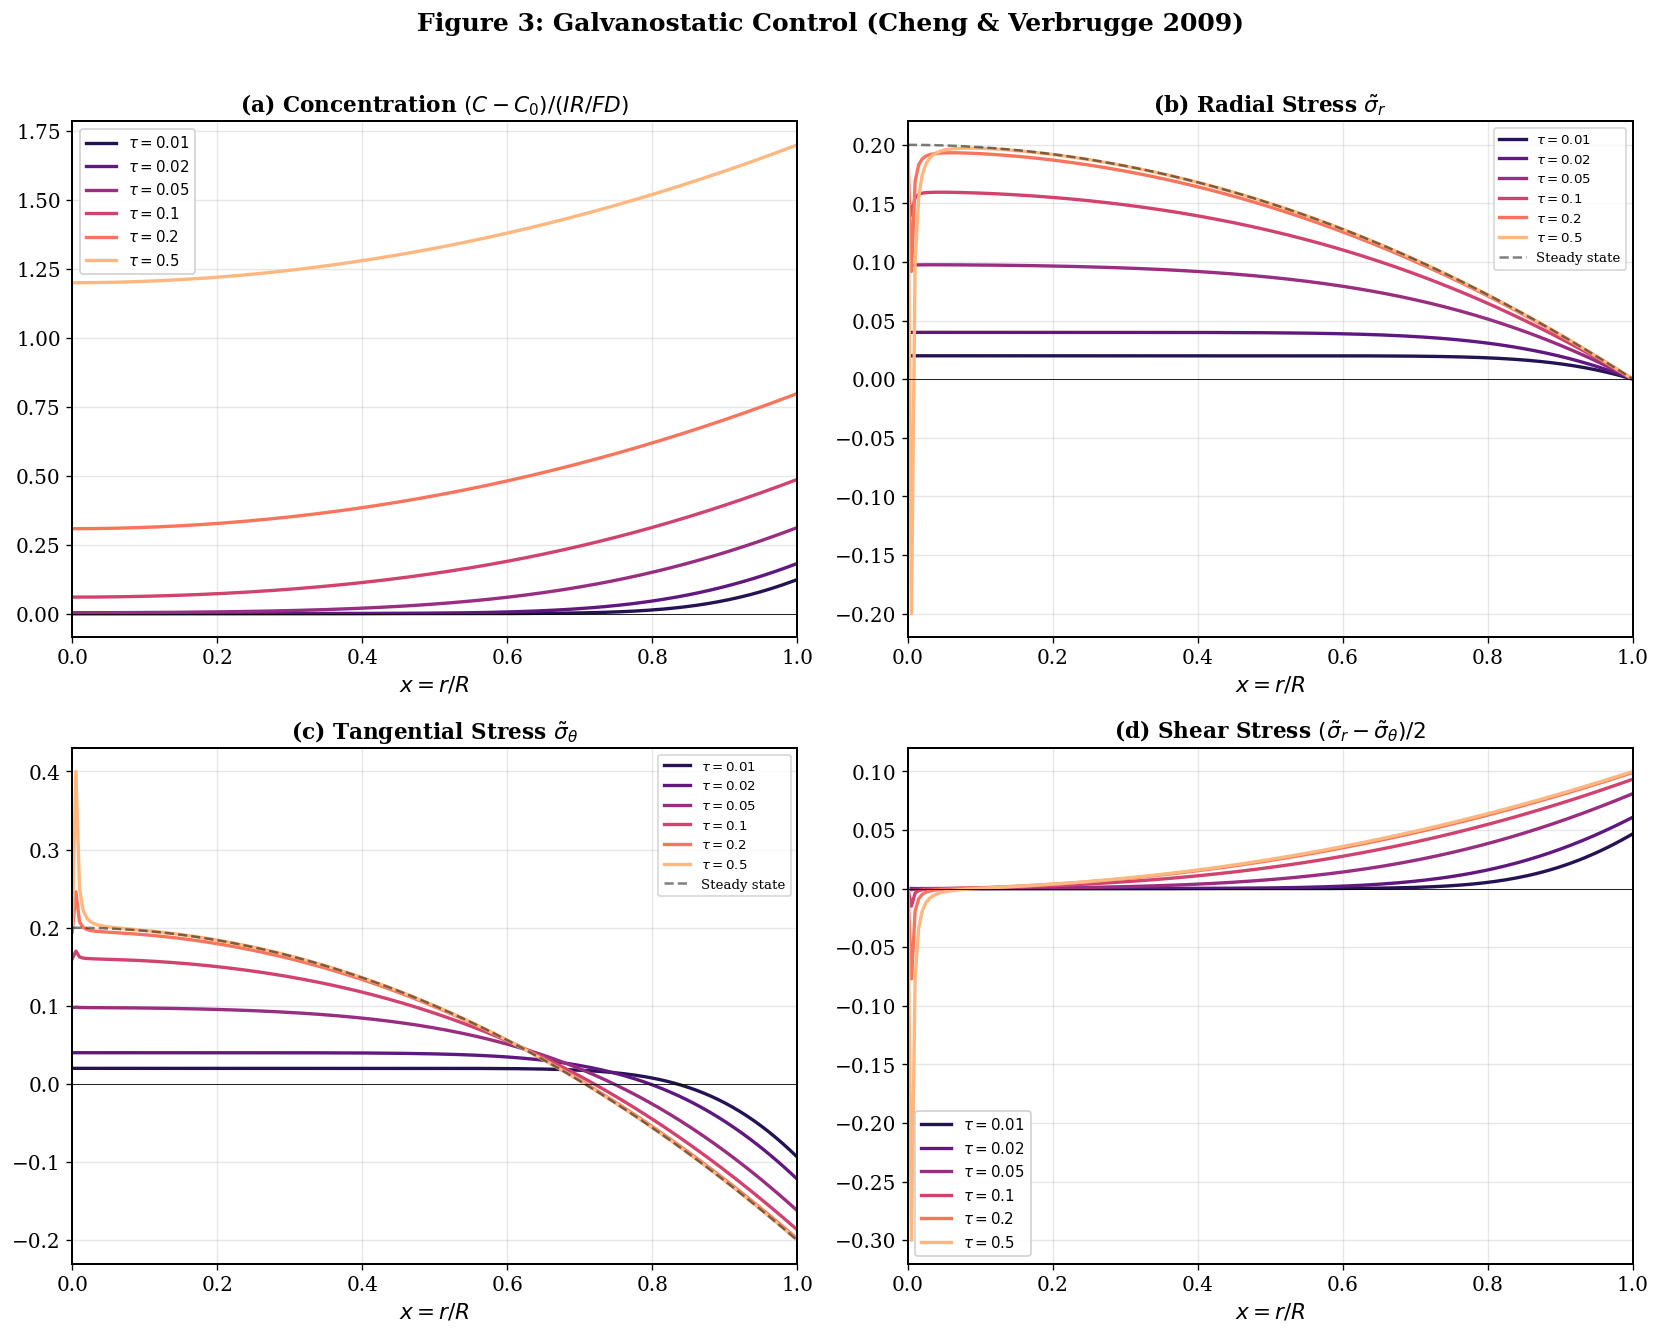

Steady-state radial stress at center (Eq.25): 1/5 = 0.2
Paper: sigma_r,max = E*Omega*IR/(15*(1-nu)*FD)


In [15]:
tau_vals_g = [0.01, 0.02, 0.05, 0.1, 0.2, 0.5]
x_g, tau_sg, C_sg = solve_diffusion(N=200, tau_max=0.55, bc_type='galvanostatic', save_at=tau_vals_g)

fig, axes = plt.subplots(2, 2, figsize=(14, 11))
colors = plt.cm.magma(np.linspace(0.15, 0.85, len(tau_vals_g)))

for tau_t, col in zip(tau_vals_g, colors):
    ic = np.argmin(np.abs(tau_sg - tau_t))
    c_prof = C_sg[ic]
    sr, st = compute_stresses(x_g, c_prof)
    sh = compute_shear(sr, st)
    lbl = f'$\\tau={tau_t}$'
    axes[0,0].plot(x_g, c_prof, color=col, lw=2, label=lbl)
    axes[0,1].plot(x_g, sr, color=col, lw=2, label=lbl)
    axes[1,0].plot(x_g, st, color=col, lw=2, label=lbl)
    axes[1,1].plot(x_g, sh, color=col, lw=2, label=lbl)

titles_g = ['(a) Concentration $(C-C_0)/(IR/FD)$',
            '(b) Radial Stress $\\tilde{\\sigma}_r$',
            '(c) Tangential Stress $\\tilde{\\sigma}_\\theta$',
            '(d) Shear Stress $(\\tilde{\\sigma}_r-\\tilde{\\sigma}_\\theta)/2$']
for ax, ttl in zip(axes.flat, titles_g):
    ax.set_xlabel('$x = r/R$', fontsize=13)
    ax.set_title(ttl, fontsize=13, fontweight='bold')
    ax.legend(fontsize=9, framealpha=0.9)
    ax.grid(True, alpha=0.3); ax.set_xlim(0,1)
    ax.axhline(0, color='k', lw=0.5)

# Mark steady-state values from Eqs. 25-26
x_ss = np.linspace(0,1,200)
axes[0,1].plot(x_ss, (1.0/5.0)*(1-x_ss**2), 'k--', lw=1.5, alpha=0.5, label='Steady state')
axes[1,0].plot(x_ss, (1.0/5.0)*(1-2*x_ss**2), 'k--', lw=1.5, alpha=0.5, label='Steady state')
axes[0,1].legend(fontsize=8); axes[1,0].legend(fontsize=8)

fig.suptitle('Figure 3: Galvanostatic Control (Cheng & Verbrugge 2009)',
             fontsize=15, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('fig3_galvanostatic.png', dpi=150, bbox_inches='tight')
plt.show()
print("Steady-state radial stress at center (Eq.25): 1/5 =", 1/5)
print("Paper: sigma_r,max = E*Omega*IR/(15*(1-nu)*FD)")

## 6. Figure 4: Galvanostatic Strain Energy vs Time

Dimensionless strain energy $\tilde{I}(\nu, \tau)$ (Eq. 28). Unlike potentiostatic, energy increases monotonically to a steady state.


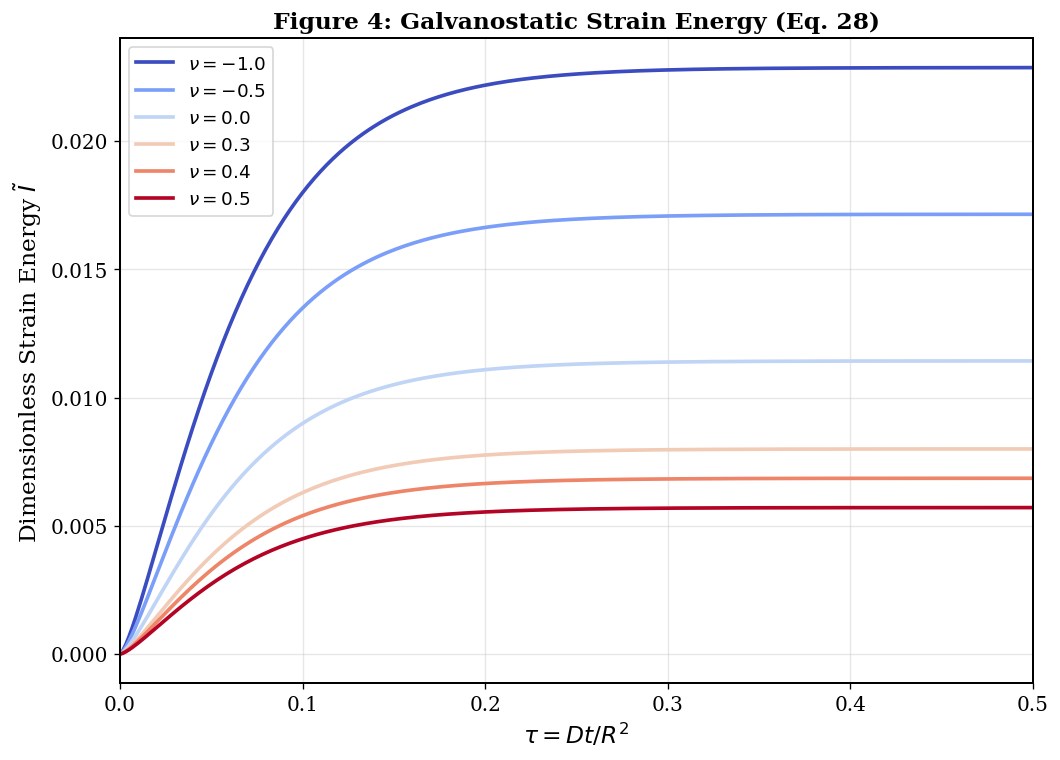

In [16]:
x_eg, tau_eg, C_eg = solve_diffusion(N=200, tau_max=0.5, bc_type='galvanostatic')
step_g = max(1, len(tau_eg)//300)
tau_sam_g = tau_eg[::step_g]; C_sam_g = C_eg[::step_g]

fig, ax = plt.subplots(figsize=(9, 6.5))

for nu, col in zip(nu_values, cmap):
    E_vals = []
    for cp in C_sam_g:
        sr, st = compute_stresses(x_eg, cp)
        E_vals.append(compute_strain_energy(x_eg, sr, st, nu))
    ax.plot(tau_sam_g, E_vals, color=col, lw=2.2, label=f'$\\nu={nu}$')

ax.set_xlabel('$\\tau = Dt/R^2$', fontsize=14)
ax.set_ylabel('Dimensionless Strain Energy $\\tilde{I}$', fontsize=14)
ax.set_title('Figure 4: Galvanostatic Strain Energy (Eq. 28)', fontsize=14, fontweight='bold')
ax.legend(fontsize=11); ax.grid(True, alpha=0.3); ax.set_xlim(0, 0.5)
plt.tight_layout()
plt.savefig('fig4_strain_energy_galvanostatic.png', dpi=150, bbox_inches='tight')
plt.show()

## 7. Key Results Verification Against Paper

Checking specific predictions from the paper:
- **Eq. 16**: Max radial stress at $\tau=0.0574$ is $\approx 0.4 \times E\Omega(C_R-C_0)/(3(1-\nu))$
- **Eq. 17**: Max tangential stress at surface at $t=0$ is $-E\Omega(C_R-C_0)/(3(1-\nu))$, i.e., $\tilde\sigma_\theta(1,0)=-1$
- **Eq. 25**: Galvanostatic steady-state radial stress: $(1/5)(1-x^2)$
- **Eq. 26**: Galvanostatic steady-state tangential stress: $(1/5)(1-2x^2)$


In [17]:
# Verify Eq. 16: max radial stress at tau ~ 0.0574
x_c, tau_c, C_c = solve_diffusion(N=200, tau_max=0.2, bc_type='potentiostatic')
max_sr = []
for cp in C_c:
    sr, _ = compute_stresses(x_c, cp)
    max_sr.append(sr[0])  # center
tau_all = np.array([t for t in tau_c])
idx_max = np.argmax(max_sr)
print(f"Max radial stress at center: {max_sr[idx_max]:.4f} at tau={tau_all[idx_max]:.4f}")
print(f"Paper Eq.16 predicts: ~0.4 at tau=0.0574")

# Verify Eq. 17: tangential at surface at t->0
_, st_early = compute_stresses(x_c, C_c[0])
print(f"\nEarly tangential stress at surface: {st_early[-1]:.4f}")
print(f"Paper Eq.17 predicts: -1.0")

# Verify galvanostatic steady state (Eqs. 25-26)
x_g2, tau_g2, C_g2 = solve_diffusion(N=200, tau_max=2.0, bc_type='galvanostatic')
sr_ss, st_ss = compute_stresses(x_g2, C_g2[-1])
print(f"\nGalvanostatic steady-state radial stress at center: {sr_ss[0]:.4f}")
print(f"Paper Eq.25 predicts: 1/5 = {1/5:.4f}")
print(f"Galvanostatic steady-state tangential at surface: {st_ss[-1]:.4f}")
print(f"Paper Eq.26 predicts: (1/5)*(1-2) = {(1/5)*(1-2):.4f}")

Max radial stress at center: 0.3856 at tau=0.0574
Paper Eq.16 predicts: ~0.4 at tau=0.0574

Early tangential stress at surface: -0.9894
Paper Eq.17 predicts: -1.0

Galvanostatic steady-state radial stress at center: 0.2001
Paper Eq.25 predicts: 1/5 = 0.2000
Galvanostatic steady-state tangential at surface: -0.1999
Paper Eq.26 predicts: (1/5)*(1-2) = -0.2000


## 9. Summary

This notebook reproduces **Figures 1–4** from Cheng & Verbrugge (2009) using a Crank-Nicolson Finite Difference Method.

### Key physical results:
- **Potentiostatic**: Stresses peak transiently then decay; max $\tilde\sigma_r \approx 0.4$ at $\tau=0.0574$
- **Galvanostatic**: Stresses increase monotonically to steady-state $\sigma_r = (1/5)(1-x^2)$
- **Strain energy**: Peak-and-decay (potentiostatic) vs monotonic increase (galvanostatic)
- **Poisson ratio** significantly affects strain energy; lower $\nu$ → higher energy

### References used:
1. Y.-T. Cheng, M.W. Verbrugge, J. Power Sources 190 (2009) 453–460
2. Class Notes on ECEG-6201 Analytical & Computational Methods by Murad Ridwan from Addis Ababa University: http://ndl.ethernet.edu.et/bitstream/123456789/87841/6/chapter4.pdf
3. Crank-Nikolson method (Wikipedia): https://en.wikipedia.org/wiki/Crank-Nicolson_method
